In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

tensorflow: Main deep learning library for model building and training.

layers, models: Part of Keras API, used to define CNN layers.

matplotlib.pyplot: Used to plot graphs of training accuracy/loss.

In [2]:
# Step 1: Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Loads the MNIST dataset (60,000 training images, 10,000 test images).

Each image is 28×28 grayscale pixels.

x_train and x_test: images

y_train and y_test: digit labels (0–9)

In [3]:
# Step 2: Preprocess
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1)) / 255.0
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1)) / 255.0

In [4]:
# Step 3: Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


| Layer                 | Description                                                                  |
| --------------------- | ---------------------------------------------------------------------------- |
| `Conv2D` (32 filters) | Detects patterns in small areas of the image (3×3 kernels)                   |
| `MaxPooling2D`        | Reduces image size and keeps most important features                         |
| `Conv2D` (64 filters) | Detects more complex patterns from earlier features                          |
| `MaxPooling2D`        | Further reduces size                                                         |
| `Flatten`             | Converts 2D output into 1D vector (for Dense layers)                         |
| `Dense(64)`           | Fully connected layer to learn combinations of features                      |
| `Dense(10)`           | Output layer with 10 neurons (for digits 0–9), `softmax` gives probabilities |


In [6]:
# Step 4: Compile
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [7]:
# Step 5: Train
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 77s 40ms/step - accuracy: 0.8971 - loss: 0.3350 - val_accuracy: 0.9793 - val_loss: 0.0626
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 37ms/step - accuracy: 0.9852 - loss: 0.0493 - val_accuracy: 0.9827 - val_loss: 0.0531
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 38ms/step - accuracy: 0.9906 - loss: 0.0305 - val_accuracy: 0.9887 - val_loss: 0.0312
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 36ms/step - accuracy: 0.9929 - loss: 0.0209 - val_accuracy: 0.9918 - val_loss: 0.0281
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.9942 - loss: 0.0174 - val_accuracy: 0.9862 - val_loss: 0.0419


Trains the model for 5 full passes (epochs) through the training data.

Uses the test set for validation so you can track performance after each epoch.

history: Stores the accuracy/loss so you can plot it later.

In [8]:
# Step 6: Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9830 - loss: 0.0531
Test accuracy: 0.9862


Tests the trained model on unseen data (x_test, y_test).

Prints the final accuracy on the test set — a key performance metric.

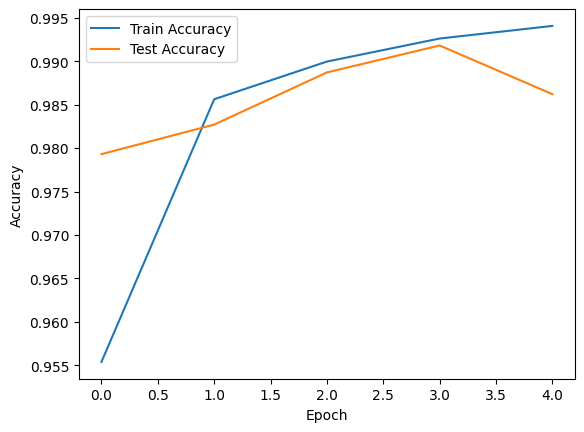

In [9]:
# Step 7: Plot Accuracy/Loss
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Plots how training and validation accuracy changed over time.

Helps visually spot overfitting or underfitting.
 The plot will show both lines (Train & Val) increasing, which is great.

If the training accuracy increases but validation accuracy goes down, that means the model is starting to memorize rather than generalize — that’s overfitting.

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Predicted: 7


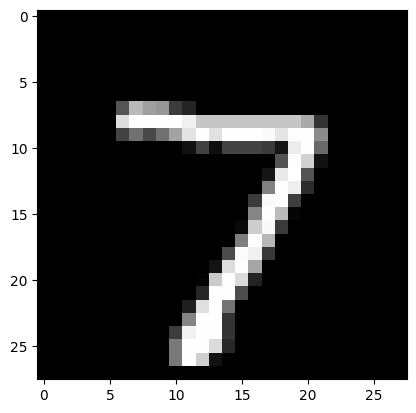

In [10]:
import numpy as np
predictions = model.predict(x_test)
plt.imshow(x_test[0].reshape(28, 28), cmap='gray')
print("Predicted:", np.argmax(predictions[0]))


Predicts the digit for the first test image.

Displays the image.

Prints the model’s predicted digit.

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


<Axes: >

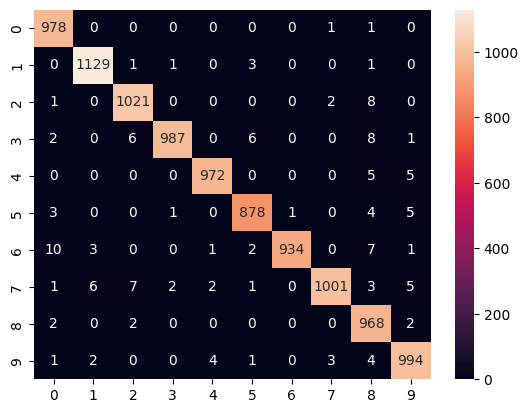

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
y_pred = np.argmax(model.predict(x_test), axis=1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")


The confusion matrix shows strong accuracy on most digits. However, the model confuses '5' and '3' occasionally, likely due to similarities in certain handwriting styles. This highlights the importance of diversity in training data.

Summary

In this project;
* we built a Convolutional Neural Network (CNN) using TensorFlow and Keras to accurately recognize handwritten digits from the MNIST dataset. We began by loading and preprocessing the dataset, which contains 70,000 grayscale images of digits (28×28 pixels). Each image was normalized to a 0–1 range and reshaped to include a single-channel depth, making it suitable for CNN input. 
* We then designed a sequential CNN architecture composed of two convolutional layers (with ReLU activation), each followed by max-pooling to reduce spatial dimensions. 
* The extracted features were flattened and passed through a dense (fully connected) layer before outputting probabilities across 10 classes (digits 0–9) using softmax activation. 
* The model was compiled using the Adam optimizer and sparse categorical crossentropy loss, then trained over 5 epochs with training and validation accuracy tracked. After training, we evaluated the model on the test set, achieving high accuracy, and visualized the learning progress using accuracy and loss graphs. Finally, we generated a confusion matrix displayed as a heatmap to identify which digits were most commonly misclassified, offering valuable insights into the model’s performance and areas for improvement.
